/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/52235.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/9273.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/18966.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/2/37825.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/2/44033.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/2/43294.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/5/11396.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/5/24408.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/5/32154.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/8/27147.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/8/32352.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/8/41463.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/0/22897.png
/kaggle/input

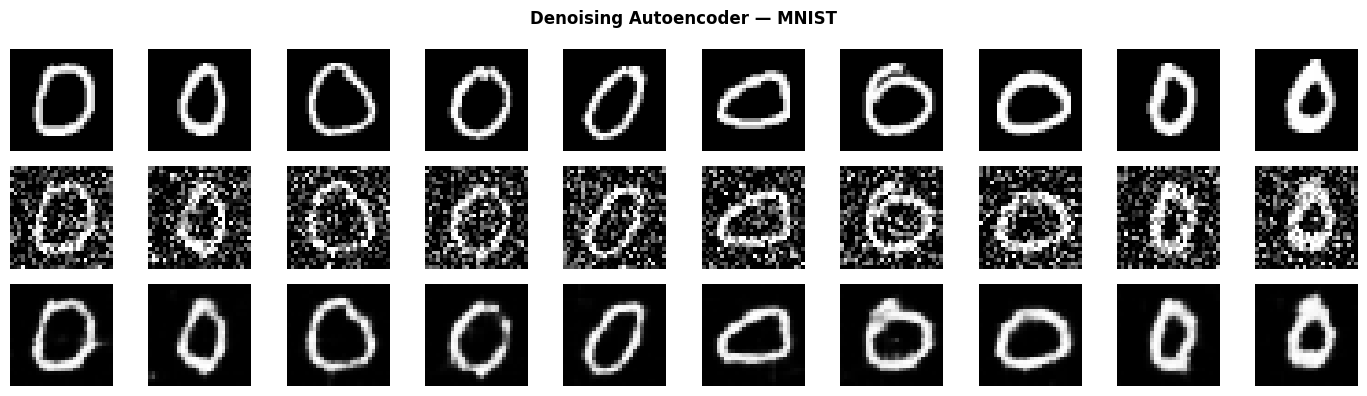

In [1]:
import numpy as np
import pandas as pd
import os, torch, torch.nn as nn, matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# Check paths
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:3]:
        print(os.path.join(dirname, filename))

import kagglehub
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


BASE = None
for root, dirs, _ in os.walk('/kaggle/input'):
    if 'training' in dirs and 'testing' in dirs:
        BASE = root
        break
    if 'train' in dirs and ('test' in dirs or 'val' in dirs):
        BASE = root
        break
print("Dataset found at:", BASE)

#  Load images 
tf = transforms.Compose([transforms.Grayscale(), transforms.ToTensor()])

train_folder = os.path.join(BASE, 'training') if os.path.exists(os.path.join(BASE,'training')) else os.path.join(BASE,'train')
test_folder  = os.path.join(BASE, 'testing')  if os.path.exists(os.path.join(BASE,'testing'))  else os.path.join(BASE,'val')

x_train = torch.stack([img for img,_ in datasets.ImageFolder(train_folder, tf)])
x_test  = torch.stack([img for img,_ in datasets.ImageFolder(test_folder,  tf)])
print(f"Train: {x_train.shape} | Test: {x_test.shape}")

# Add noise 
def add_noise(x): return torch.clamp(x + 0.4*torch.randn_like(x), 0, 1)
xtn = add_noise(x_train)
xvn = add_noise(x_test)

train_dl = DataLoader(TensorDataset(xtn, x_train), batch_size=512, shuffle=True, num_workers=2)

#  Model
class DAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64,32,2,stride=2), nn.ReLU(),
            nn.ConvTranspose2d(32,1,2,stride=2),  nn.Sigmoid())
    def forward(self, x): return self.dec(self.enc(x))

model   = DAE().to(device)
opt     = torch.optim.Adam(model.parameters(), 1e-3)
loss_fn = nn.MSELoss()

# Train 
for ep in range(1, 11):
    model.train(); total = 0
    for n, c in train_dl:
        n, c = n.to(device), c.to(device)
        l = loss_fn(model(n), c)
        opt.zero_grad(); l.backward(); opt.step()
        total += l.item() * n.size(0)
    print(f"Epoch {ep:02d} | Loss: {total/len(train_dl.dataset):.5f}")

#  Visualize
model.eval()
with torch.no_grad():
    out = model(xvn[:10].to(device)).cpu()

fig, axes = plt.subplots(3, 10, figsize=(14, 4))
for i in range(10):
    for r, imgs, lbl in zip(range(3), [x_test, xvn, out], ['Original','Noisy','Denoised']):
        axes[r,i].imshow(imgs[i].squeeze(), cmap='gray'); axes[r,i].axis('off')
        if i == 0: axes[r,0].set_ylabel(lbl, fontsize=10)
plt.suptitle('Denoising Autoencoder — MNIST', fontweight='bold')
plt.tight_layout(); plt.show()